Entrega del Laboratorio 1 del grupo 11
 Sebastian Vargas Otero - 202323722 
 Juan Diego Ramierez - 20242


Primero de todo importaremos las librerias que nos serviran para este laboratorio

## Importación de librerías

Importaremos las librerías necesarias para explorar, analizar y visualizar el conjunto de datos.

In [131]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

Primero de todo lo que haremos sera guardar los datos y copiarlos para trabajar sobre ellos y ver que estrategias podemos usar en ellos


## Carga y copia de los datos

Cargaremos el conjunto de datos de entrenamiento y crearemos una copia para realizar el análisis sin modificar directamente los datos originales.

In [132]:
Datos_temperatura = pd.read_csv("./data/Datos Lab 1.csv")
datos = Datos_temperatura.copy()
datos.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Con .info() podemos ver un poco mas de como son los datos, esto sive para poder comenzar a ver su funcionalidad y como los podemos dividir.


## Inspección inicial

Observaremos las primeras filas para conocer la estructura del conjunto de datos y verificar que la información se haya cargado correctamente.

In [133]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

Aca abrimos el diccionario para ver las definiciones dadas de la informacion y poder analizar los datos de manera completa

## Diccionario de datos

Consultaremos el diccionario para comprender el significado de las variables y distinguir entre variables numéricas, categóricas y relacionadas con la fecha.

In [134]:
diccionario = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Al analizar todo podemos ver que las fechas no son tipo fecha si no un string, para trabajar mejor con estas vamos a cambiarlas al formato correcto

## Conversión de la fecha

La columna `fecha` fue cargada como texto. La convertiremos al tipo fecha para poder extraer y comparar el año, el mes y el día del año.

In [135]:
datos["fecha"]=pd.to_datetime(datos["fecha"], format="%Y-%m-%d")
datos["fecha"].head()

0   2009-01-01
1   2009-01-02
2   2009-01-03
3   2009-01-04
4   2009-01-05
Name: fecha, dtype: datetime64[us]

Ahora ya con toda la informacion importada y con la informacion clara y sus descripciones veremos los porsentajes de vacio en cada columna de los datos

## Valores faltantes

Calcularemos el porcentaje de valores faltantes en cada columna. Esta información permitirá identificar variables incompletas y definir posteriormente una estrategia de tratamiento.

In [136]:
((datos.isnull().sum()/datos.shape[0])*100).sort_values(ascending=False).round(3)

temp_max_manana      3.688
viento_min           3.533
estacion_anio        3.416
mes                  3.416
anio                 3.339
humedad_max          3.339
viento_media         3.339
viento_max           3.144
humedad_min          3.106
viento_norte         3.106
presion_desv         3.106
rafaga_desv          3.067
direccion_viento     3.067
rafaga_media         3.028
registros_del_dia    2.989
presion_media        2.911
presion_min          2.873
humedad_media        2.873
rafaga_max           2.834
rafaga_min           2.795
viento_desv          2.795
fecha                2.795
sector_viento        2.756
dia_del_anio         2.640
presion_max          2.484
viento_este          2.484
humedad_desv         2.368
dtype: float64

Ahora analizaremos con el .describe() los valores principales de los datos

## Estadísticas descriptivas

Revisaremos las estadísticas principales de las variables numéricas para conocer sus rangos, valores centrales y dispersión, y detectar posibles valores atípicos.

In [137]:
datos.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2504,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,2012-06-29 14:19:10.159744,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
min,2009-01-01 00:00:00,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,2010-09-22 18:00:00,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,2012-07-04 12:00:00,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,2014-03-30 06:00:00,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,2015-12-31 00:00:00,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000
std,NaN,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199


Ahora ya comenzaremos a ver la calidad de los datos, para esto primero veremos si hay datos duplicados

## Duplicados completos

Verificaremos si existen filas completamente duplicadas. Estos registros podrían repetir exactamente la misma observación y afectar el análisis.

In [138]:
print(f"Existen {datos.duplicated(keep = False).sum()} filas duplicadas en los datos.")

Existen 8 filas duplicadas en los datos.


## Revisión de fechas repetidas

Comprobaremos cuántas filas tienen fechas repetidas. Una fecha repetida no implica necesariamente que la fila completa sea un duplicado, por lo que los registros deben inspeccionarse antes de eliminarlos.

In [139]:
print(f"Existen {datos['fecha'].duplicated(keep = False).sum()} filas con fecha duplicada.")

Existen 108 filas con fecha duplicada.


Ahora veremos los datos que tienen fechas nulas, para saber cuantas son y poder borrar esos datos ya que no nos ayudan ni sirve.

## Fechas nulas

Contaremos las fechas faltantes porque una fecha nula impide verificar el año, el mes y el día del año asociados al registro.

In [140]:
datos["fecha"].isnull().sum()

np.int64(72)

## Eliminación de fechas faltantes

Si las fechas faltantes son pocas, eliminaremos únicamente esas filas. No asignaremos una fecha provisional, porque sería información inventada y podría generar incoherencias.

In [141]:
datos= datos.dropna(subset=['fecha'])
datos["fecha"].isnull().sum()

np.int64(0)

Aca comparamos las filas que estan repetidas en fecha para darnos cuenta que estas son datos duplicados que podemos depurar.

## Inspección de fechas repetidas

Mostraremos los registros con fechas repetidas y el número de apariciones de cada fecha. Esto permite distinguir duplicados reales de observaciones diferentes del mismo día.

In [142]:
dup_table = (
    datos[datos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(Repeticiones=datos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['Repeticiones', 'fecha'], ascending=[False, True])
)
dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,Repeticiones
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000,2
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,2
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,2
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000,2
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,2
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,2
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,2


## Depuración de fechas repetidas

Después de inspeccionar los registros, conservaremos una sola observación por fecha, asumiendo que el conjunto de datos debe tener una fila diaria. Esta decisión debe quedar justificada en el análisis.

In [143]:
datos = datos.drop_duplicates(subset=['fecha'], keep='first')

duplicados_restantes = datos['fecha'].duplicated(keep=False).sum()
print(f"Existen {duplicados_restantes} fechas duplicadas después de la limpieza.")

Existen 0 fechas duplicadas después de la limpieza.


## Controles generales de calidad

Realizaremos verificaciones adicionales sobre tipos de datos, valores faltantes, duplicados y rango temporal para evaluar la calidad del conjunto después de la limpieza inicial.

In [144]:
# Tipos de datos
datos.dtypes

# Valores faltantes
faltantes = datos.isna().sum().sort_values(ascending=False)
faltantes[faltantes > 0]

# Filas completamente duplicadas
datos.duplicated().sum()

# Fechas repetidas
datos["fecha"].duplicated().sum()

# Fechas fuera del rango esperado
datos["fecha"].min(), datos["fecha"].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2015-12-31 00:00:00'))

## Detección de valores atípicos

Usaremos diagramas de caja para identificar valores extremos en las variables numéricas. Estos valores no se eliminarán automáticamente, porque podrían representar fenómenos meteorológicos reales; primero deben analizarse y justificarse.

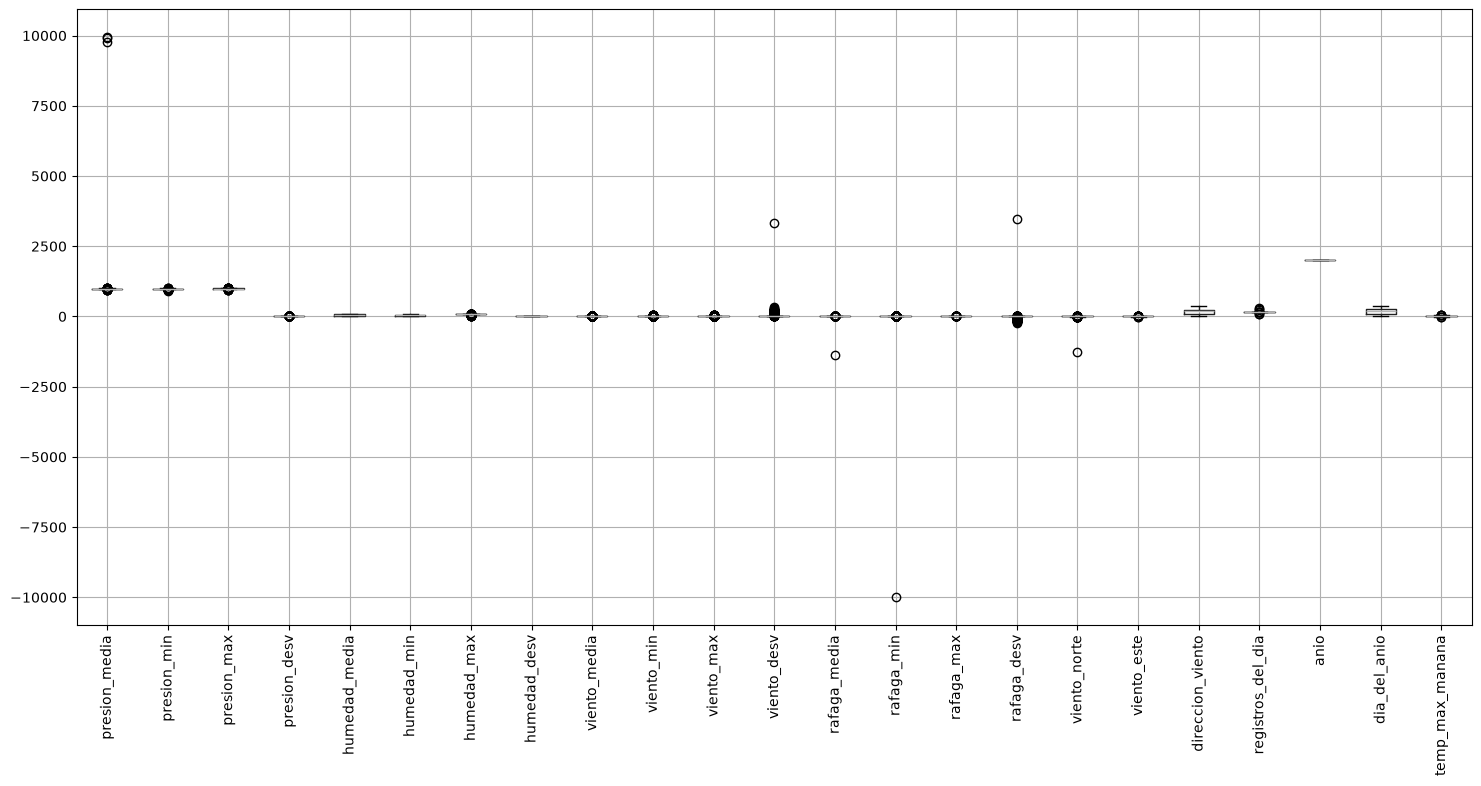

In [145]:
datos.select_dtypes(include="number").boxplot(
    figsize=(18, 8),
    rot=90
)
plt.show()

In [147]:
datos.select_dtypes(include="object").nunique()
for columna in datos.select_dtypes(include="object"):
    print(f"\n{columna}:")
    print(datos[columna].value_counts(dropna=False))


estacion_anio:
estacion_anio
primavera               505
invierno                504
otono                   479
verano                  459
NaN                      87
Inverano                 66
Estacion_Desconocida     62
VERANO_INVIERNO          58
East                     48
VERANO                   18
berano                   17
autumn                   17
primaveraa               15
winter                   15
fall                     14
verno                    13
otoño                    11
Primavera                10
Otoño                    10
invierno                  9
Verano                    9
PRIMAVERA                 9
invernio                  9
Invierno                  9
INVIERNO                  8
OTONO                     8
primav                    6
spring                    6
summer                    5
Name: count, dtype: int64

mes:
mes
May        122
July       120
August     119
January    116
March      116
          ... 
junio       16
JANUARY     14
ap

C:\Users\sebas\AppData\Local\Temp\ipykernel_28480\583941038.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  datos.select_dtypes(include="object").nunique()
C:\Users\sebas\AppData\Local\Temp\ipykernel_28480\583941038.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration